# 05. Linear and Logistic Models as Predictive Baselines

When a machine-learning project begins, many teams jump immediately to ensembles, boosting, or deep architectures. In decision science, that is often premature. A disciplined baseline provides a number to beat and a way to clarify the task. It clarifies the task, checks whether the signal is mostly linear or monotone, produces interpretable anchors for stakeholders, and reveals whether added complexity is earning its keep.

This lecture studies two such baselines: a linear model for a continuous operational target and a logistic model for a binary risk target. We will work with a synthetic service-operations panel where a software platform wants to forecast next-month support burden and estimate the risk of a serious service breach. The notebook emphasizes three ideas that recur throughout the literature: predictive modeling should stay tied to the decision problem it serves (Breiman, 2001; Domingos, 2012), the boundaries between "statistics" and "machine learning" are often less important than the modeling discipline itself (Bzdok et al., 2018), and probability predictions deserve calibration scrutiny rather than discrimination metrics alone (Van Calster et al., 2019).

## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why linear and logistic models remain strong predictive baselines for tabular decision problems.
2. Fit a stabilized linear baseline for a continuous outcome and a logistic baseline for a binary outcome.
3. Interpret standardized numeric coefficients and category adjustments in predictive, non-causal language.
4. Compare a fitted baseline to a trivial null model and to a richer nonlinear model.
5. Diagnose where a simple baseline is already sufficient and where it still misses important structure.
6. Use baseline models as operational anchors for later model comparison rather than treating them as disposable preliminaries.


## 1. Why Baselines Matter

A good predictive baseline does at least four jobs.

| Baseline role | Why it matters in practice |
|---|---|
| Sanity check | Confirms that the feature set carries more signal than a trivial constant prediction |
| Interpretability anchor | Gives stakeholders a transparent first model before more flexible alternatives are introduced |
| Error benchmark | Forces later models to justify their extra complexity with real out-of-sample gains |
| Workflow debugger | Makes it easier to spot leakage, scaling mistakes, and target-definition problems |

For this lecture we use slightly regularized linear baselines rather than raw unpenalized least squares. That choice is still consistent with the spirit of a simple model: service features in operational datasets are often correlated, and a mild amount of shrinkage makes the baseline more stable without turning it into a black box. The next lecture will study regularization in a more systematic way.


In [1]:
# Section focus: 1. Why Baselines Matter.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)


In [2]:
# Section focus: 1. Why Baselines Matter.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_one_hot_encoder(drop=None):
    """Construct the one hot encoder helper used in the 05. Linear and Logistic Models as Predictive Baselines workflow.
    
    Parameters
    ----------
    drop : object
        The drop setting that controls the one hot encoder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)


def build_preprocessor(numeric_features, categorical_features, *, drop_first=True):
    """Build the preprocessor object used in the 05. Linear and Logistic Models as Predictive Baselines analysis.
    
    Parameters
    ----------
    numeric_features : object
        Numeric columns transformed or modeled in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    drop_first : object
        The drop first setting that controls the preprocessor calculation in this notebook.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the preprocessor workflow.
    """
    drop = "first" if drop_first else None
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_one_hot_encoder(drop=drop)),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def simulate_service_panel(n_accounts=900, n_months=12, random_state=2026):
    """Create a simulated service panel data set for the 05. Linear and Logistic Models as Predictive Baselines case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    n_months : object
        Count or size setting for the service panel calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    months = np.arange(1, n_months + 1)

    regions = np.array(["North America", "Europe", "APAC", "LATAM"])
    tiers = np.array(["Basic", "Growth", "Premium", "Strategic"])
    industries = np.array(["SaaS", "FinTech", "Healthcare", "Manufacturing"])

    rows = []
    for account_number in range(1, n_accounts + 1):
        region = rng.choice(regions, p=[0.38, 0.25, 0.22, 0.15])
        tier = rng.choice(tiers, p=[0.24, 0.36, 0.28, 0.12])
        industry = rng.choice(industries)

        account_complexity = rng.normal(0, 1)
        sponsor_strength = rng.normal(0, 1)
        base_usage = rng.beta(4, 2)
        active_seats = np.exp(
            rng.normal(
                3.9 + 0.25 * (tier == "Premium") + 0.55 * (tier == "Strategic"),
                0.35,
            )
        )

        for month_index in months:
            release_shock = 1 if month_index >= 9 else 0
            seasonal = np.sin(2 * np.pi * month_index / 12)

            usage_ratio = np.clip(
                base_usage
                + 0.10 * sponsor_strength
                - 0.06 * account_complexity
                - 0.10 * release_shock
                + rng.normal(0, 0.09),
                0.02,
                0.99,
            )
            adoption_breadth = np.clip(
                sigmoid(
                    0.20
                    + 1.10 * usage_ratio
                    + 0.40 * sponsor_strength
                    - 0.40 * account_complexity
                    + rng.normal(0, 0.70)
                ),
                0.02,
                0.99,
            )
            backlog_ratio = np.clip(
                0.40
                + 0.18 * account_complexity
                - 0.12 * sponsor_strength
                + 0.12 * release_shock
                + rng.normal(0, 0.12),
                0.01,
                0.99,
            )
            critical_incidents_30d = int(
                max(
                    0,
                    rng.poisson(np.exp(-1.4 + 1.1 * account_complexity + 0.9 * backlog_ratio + 0.35 * release_shock)),
                )
            )
            avg_response_hours_30d = np.exp(
                0.90
                + 0.22 * account_complexity
                - 0.14 * sponsor_strength
                + 0.60 * backlog_ratio
                + 0.16 * release_shock
                + rng.normal(0, 0.20)
            )
            prior_escalation_rate = np.clip(
                0.10
                + 0.10 * account_complexity
                - 0.08 * sponsor_strength
                + 0.04 * (month_index > 4)
                + rng.normal(0, 0.05),
                0,
                1,
            )

            support_hours_next_month = (
                10
                + 0.045 * active_seats
                + 12 * backlog_ratio
                + 1.8 * critical_incidents_30d
                + 1.1 * avg_response_hours_30d
                + 5 * max(0.65 - usage_ratio, 0)
                + 4 * (tier == "Strategic")
                + 3 * (region == "LATAM")
                + 6 * release_shock
                + 4 * max(account_complexity, 0)
                + 5 * ((critical_incidents_30d >= 3) and (release_shock == 1))
                + rng.normal(0, 4.5)
            )

            breach_risk = (
                -2.8
                + 1.10 * account_complexity
                - 0.85 * sponsor_strength
                + 0.90 * backlog_ratio
                + 0.23 * critical_incidents_30d
                + 0.15 * np.log1p(avg_response_hours_30d)
                + 0.80 * release_shock
                + 0.25 * (region == "LATAM")
                + 0.15 * (tier == "Basic")
                + 0.20 * seasonal
                + 0.50 * ((usage_ratio < 0.45) and (backlog_ratio > 0.55))
            )
            breach_next_month = rng.binomial(1, sigmoid(breach_risk))

            rows.append(
                {
                    "account_id": f"A{account_number:04d}",
                    "month_index": int(month_index),
                    "region": region,
                    "tier": tier,
                    "industry": industry,
                    "active_seats": float(active_seats),
                    "usage_ratio": float(usage_ratio),
                    "adoption_breadth": float(adoption_breadth),
                    "backlog_ratio": float(backlog_ratio),
                    "critical_incidents_30d": critical_incidents_30d,
                    "avg_response_hours_30d": float(avg_response_hours_30d),
                    "prior_escalation_rate": float(prior_escalation_rate),
                    "release_shock": release_shock,
                    "support_hours_next_month": float(support_hours_next_month),
                    "breach_next_month": breach_next_month,
                }
            )

    return pd.DataFrame(rows)


def make_reference_level_lookup(fitted_preprocessor, categorical_features):
    """Construct the reference level lookup helper used in the 05. Linear and Logistic Models as Predictive Baselines workflow.
    
    Parameters
    ----------
    fitted_preprocessor : object
        The fitted preprocessor setting that controls the reference level lookup calculation in this notebook.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the reference level lookup calculation and reused by later cells.
    """
    encoder = fitted_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
    return {feature: categories[0] for feature, categories in zip(categorical_features, encoder.categories_)}


def clean_feature_label(feature_name, reference_lookup):
    """Clean feature label so it can be interpreted in the 05. Linear and Logistic Models as Predictive Baselines workflow.
    
    Parameters
    ----------
    feature_name : object
        Column or variable name used to select information from the input table.
    reference_lookup : object
        The reference lookup setting that controls the feature label calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the feature label calculation and reused by later cells.
    """
    if "__" in feature_name:
        prefix, raw = feature_name.split("__", 1)
    else:
        prefix, raw = "", feature_name

    if prefix in {"num", "numeric"}:
        return raw.replace("_", " ")

    if prefix in {"cat", "categorical"}:
        for field, reference in reference_lookup.items():
            field_prefix = f"{field}_"
            if raw.startswith(field_prefix):
                level = raw[len(field_prefix):]
                return f"{field}: {level} vs {reference}"
        return raw.replace("_", " ")

    return raw.replace("_", " ")


def coefficient_frame(fitted_pipeline, model_kind, categorical_features):
    """Carry out the coefficient frame step used in the 05. Linear and Logistic Models as Predictive Baselines workflow.
    
    Parameters
    ----------
    fitted_pipeline : object
        Model object, learner, or pipeline being fitted, scored, or explained.
    model_kind : object
        Model object fitted, evaluated, or compared in this workflow.
    categorical_features : object
        Categorical columns encoded for the model workflow.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    reference_lookup = make_reference_level_lookup(preprocessor, categorical_features)
    labels = [clean_feature_label(name, reference_lookup) for name in feature_names]

    if model_kind == "regression":
        frame = pd.DataFrame(
            {
                "feature": labels,
                "coefficient": model.coef_,
            }
        )
        frame["abs_coefficient"] = frame["coefficient"].abs()
        return frame.sort_values("abs_coefficient", ascending=False), reference_lookup

    frame = pd.DataFrame(
        {
            "feature": labels,
            "log_odds_coefficient": model.coef_[0],
            "odds_multiplier": np.exp(model.coef_[0]),
        }
    )
    frame["abs_coefficient"] = frame["log_odds_coefficient"].abs()
    return frame.sort_values("abs_coefficient", ascending=False), reference_lookup


## 2. Synthetic Service-Operations Dataset

We will study the same kind of operational environment that motivated the last notebook: a software platform with recurring customer accounts and evolving service conditions over time. Here, however, we care about two different predictive targets:

1. **`support_hours_next_month`**: a continuous estimate of next-month support burden.
2. **`breach_next_month`**: a binary indicator for whether the account experiences a serious service breach next month.

Using one shared feature space but two different targets is useful pedagogically. It shows why linear and logistic models are often the first sensible baseline family for tabular workflows: they adapt naturally to different target types while keeping preprocessing, interpretation, and evaluation logic coherent.


,quantity,value
0,Rows,10800.000000
1,Unique accounts,900.000000
2,Average support hours,29.380000
3,Overall breach rate,0.260000
4,Late-period breach rate (months 9-12),0.344000


,account_id,month_index,region,tier,industry,active_seats,usage_ratio,adoption_breadth,backlog_ratio,critical_incidents_30d,avg_response_hours_30d,prior_escalation_rate,release_shock,support_hours_next_month,breach_next_month
0,A0001,1,North America,Premium,FinTech,58.612,0.645,0.724,0.567,3,4.795,0.182,0,29.539,0
1,A0001,2,North America,Premium,FinTech,58.612,0.639,0.608,0.557,2,5.593,0.127,0,35.496,0
2,A0001,3,North America,Premium,FinTech,58.612,0.702,0.778,0.711,3,5.185,0.232,0,38.778,1
3,A0001,4,North America,Premium,FinTech,58.612,0.506,0.812,0.646,2,7.517,0.346,0,45.844,0
4,A0001,5,North America,Premium,FinTech,58.612,0.520,0.762,0.522,0,3.945,0.243,0,35.264,0
5,A0001,6,North America,Premium,FinTech,58.612,0.713,0.572,0.456,0,3.313,0.157,0,23.234,0
6,A0001,7,North America,Premium,FinTech,58.612,0.527,0.658,0.429,2,6.208,0.199,0,39.449,0
7,A0001,8,North America,Premium,FinTech,58.612,0.566,0.516,0.729,0,6.428,0.193,0,34.717,1


,month_index,mean_support_hours,breach_rate
0,1,26.094,0.226
1,2,26.122,0.217
2,3,26.005,0.214
3,4,25.938,0.234
4,5,26.204,0.230
5,6,25.941,0.227
6,7,26.013,0.194
7,8,25.962,0.198
8,9,36.102,0.329
9,10,36.183,0.329


,tier,rows,mean_support_hours,breach_rate
0,Basic,2604,27.116,0.256
1,Growth,3672,28.997,0.260
2,Premium,3144,29.904,0.271
3,Strategic,1380,33.447,0.241


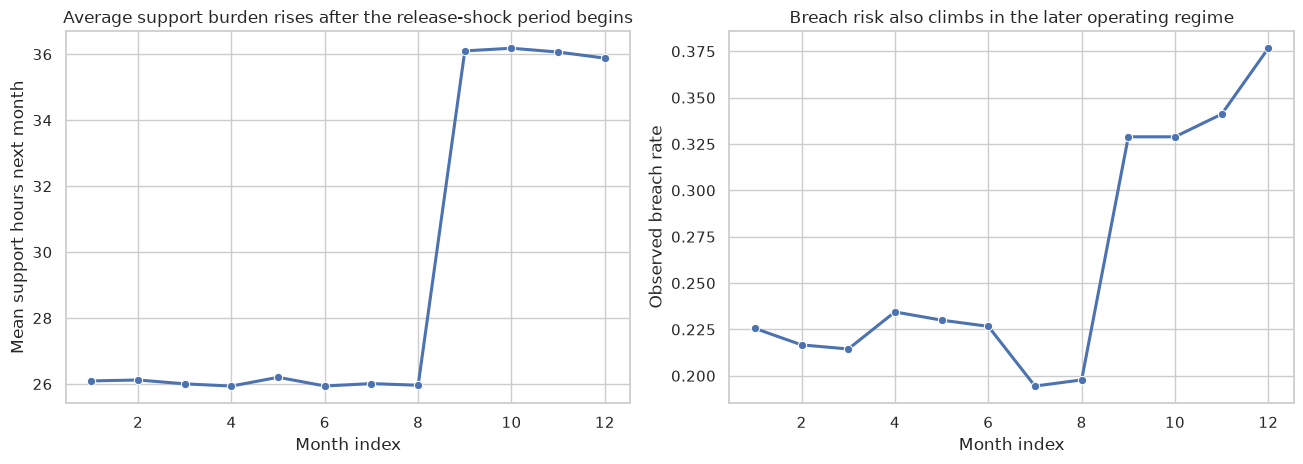

In [3]:
# Section focus: 2. Synthetic Service-Operations Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

df = simulate_service_panel()

panel_overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df)},
        {"quantity": "Unique accounts", "value": df["account_id"].nunique()},
        {"quantity": "Average support hours", "value": round(df["support_hours_next_month"].mean(), 2)},
        {"quantity": "Overall breach rate", "value": round(df["breach_next_month"].mean(), 3)},
        {
            "quantity": "Late-period breach rate (months 9-12)",
            "value": round(df.loc[df["month_index"] >= 9, "breach_next_month"].mean(), 3),
        },
    ]
)

monthly_summary = (
    df.groupby("month_index", as_index=False)
    .agg(
        mean_support_hours=("support_hours_next_month", "mean"),
        breach_rate=("breach_next_month", "mean"),
    )
)

tier_summary = (
    df.groupby("tier", as_index=False)
    .agg(
        rows=("account_id", "size"),
        mean_support_hours=("support_hours_next_month", "mean"),
        breach_rate=("breach_next_month", "mean"),
    )
)

smart_display(panel_overview)
smart_display(df.head(8))
smart_display(monthly_summary.round(3))
smart_display(tier_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

sns.lineplot(data=monthly_summary, x="month_index", y="mean_support_hours", marker="o", linewidth=2.2, ax=axes[0])
axes[0].set_title("Average support burden rises after the release-shock period begins")
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Mean support hours next month")

sns.lineplot(data=monthly_summary, x="month_index", y="breach_rate", marker="o", linewidth=2.2, ax=axes[1])
axes[1].set_title("Breach risk also climbs in the later operating regime")
axes[1].set_xlabel("Month index")
axes[1].set_ylabel("Observed breach rate")

plt.tight_layout()
plt.show()


The later months are deliberately harder. A release shock raises support load and breach risk at the same time. That gives the notebook a realistic tension: even a well-constructed baseline may still struggle in the operational tail or under a new regime. The question is not whether the baseline is flawless. The question is whether it is already strong enough to become a serious benchmark for later models.


## 3. Linear Baseline for Next-Month Support Burden

A standardized linear model for a continuous target takes the form

$$
\widehat{y} = \beta_0 + z^\top \beta,
$$

where the numeric predictors have been standardized and the categorical predictors are represented by reference-coded indicator variables. In this notebook we use a ridge-style baseline rather than unpenalized least squares, because many operational features are correlated and a mild amount of shrinkage tends to stabilize predictive coefficients.

To keep the evaluation honest, we train on months 1 through 8 and test on months 11 and 12. That means the baseline must generalize into the later release-shock regime, not settle for interpolation among similar rows.


,model,mae,rmse,r_squared,mean_prediction
0,Null mean predictor,11.481,16.671,-0.552,26.035
1,Ridge linear baseline,6.411,7.721,0.667,30.114


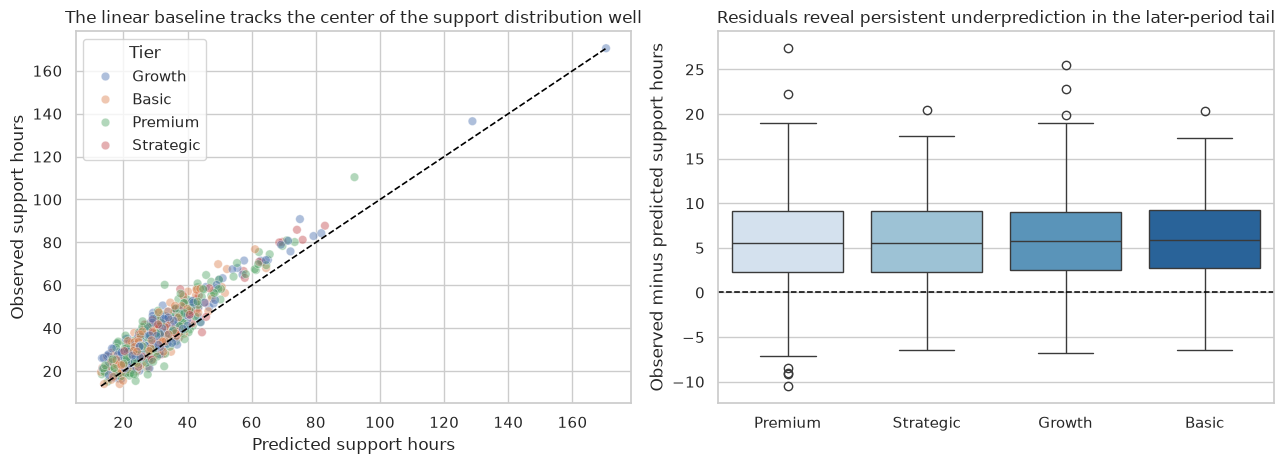

In [4]:
# Section focus: 3. Linear Baseline for Next-Month Support Burden.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

train = df[df["month_index"] <= 8].copy()
test = df[df["month_index"] >= 11].copy()

numeric_features = [
    "active_seats",
    "usage_ratio",
    "adoption_breadth",
    "backlog_ratio",
    "critical_incidents_30d",
    "avg_response_hours_30d",
    "prior_escalation_rate",
    "release_shock",
]
categorical_features = ["region", "tier", "industry"]
features = numeric_features + categorical_features

support_null_prediction = np.repeat(train["support_hours_next_month"].mean(), len(test))

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features, drop_first=True)),
        ("model", Ridge(alpha=1.0)),
    ]
)
ridge_pipeline.fit(train[features], train["support_hours_next_month"])
support_prediction = ridge_pipeline.predict(test[features])

regression_results = pd.DataFrame(
    [
        {
            "model": "Null mean predictor",
            "mae": mean_absolute_error(test["support_hours_next_month"], support_null_prediction),
            "rmse": mean_squared_error(test["support_hours_next_month"], support_null_prediction) ** 0.5,
            "r_squared": r2_score(test["support_hours_next_month"], support_null_prediction),
            "mean_prediction": support_null_prediction.mean(),
        },
        {
            "model": "Ridge linear baseline",
            "mae": mean_absolute_error(test["support_hours_next_month"], support_prediction),
            "rmse": mean_squared_error(test["support_hours_next_month"], support_prediction) ** 0.5,
            "r_squared": r2_score(test["support_hours_next_month"], support_prediction),
            "mean_prediction": support_prediction.mean(),
        },
    ]
)
smart_display(regression_results.round(3))

test_regression = test.copy()
test_regression["predicted_support_hours"] = support_prediction
test_regression["residual"] = test_regression["support_hours_next_month"] - test_regression["predicted_support_hours"]
plot_sample = test_regression.sample(n=min(900, len(test_regression)), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

sns.scatterplot(
    data=plot_sample,
    x="predicted_support_hours",
    y="support_hours_next_month",
    hue="tier",
    alpha=0.45,
    s=38,
    ax=axes[0],
)
min_axis = min(plot_sample["predicted_support_hours"].min(), plot_sample["support_hours_next_month"].min())
max_axis = max(plot_sample["predicted_support_hours"].max(), plot_sample["support_hours_next_month"].max())
axes[0].plot([min_axis, max_axis], [min_axis, max_axis], linestyle="--", color="black", linewidth=1.2)
axes[0].set_title("The linear baseline tracks the center of the support distribution well")
axes[0].set_xlabel("Predicted support hours")
axes[0].set_ylabel("Observed support hours")
axes[0].legend(title="Tier", loc="upper left")

sns.boxplot(data=test_regression, x="tier", y="residual", palette="Blues", ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black", linewidth=1.1)
axes[1].set_title("Residuals reveal persistent underprediction in the later-period tail")
axes[1].set_xlabel("")
axes[1].set_ylabel("Observed minus predicted support hours")

plt.tight_layout()
plt.show()


The Linear Baseline for Next-Month Support Burden result matters when it changes the next move. The practical reading asks what evidence would change the model or operating rule.


,categorical_field,reference_level
0,region,APAC
1,tier,Basic
2,industry,FinTech


,feature,coefficient
4,critical incidents 30d,4.767
3,backlog ratio,3.051
5,avg response hours 30d,2.402
0,active seats,1.127
6,prior escalation rate,0.447
1,usage ratio,-0.355
2,adoption breadth,-0.015
7,release shock,0.000


,feature,coefficient
13,tier: Strategic vs Basic,4.091000
9,region: LATAM vs APAC,3.401000
8,region: Europe vs APAC,0.460000
10,region: North America vs APAC,0.351000
12,tier: Premium vs Basic,0.333000
16,industry: SaaS vs FinTech,-0.261000
15,industry: Manufacturing vs FinTech,0.209000
14,industry: Healthcare vs FinTech,0.168000


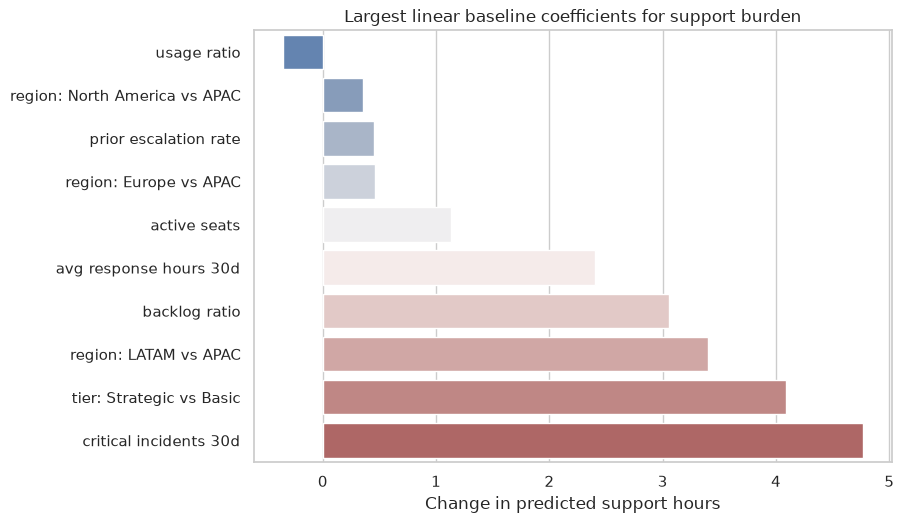

In [5]:
# Section focus: 3. Linear Baseline for Next-Month Support Burden.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

regression_coefficients, regression_reference_levels = coefficient_frame(
    ridge_pipeline,
    model_kind="regression",
    categorical_features=categorical_features,
)

regression_reference_table = pd.DataFrame(
    {
        "categorical_field": list(regression_reference_levels.keys()),
        "reference_level": list(regression_reference_levels.values()),
    }
)

regression_top_numeric = regression_coefficients[~regression_coefficients["feature"].str.contains(":")].head(8)
regression_top_categories = regression_coefficients[regression_coefficients["feature"].str.contains(":")].head(8)

smart_display(regression_reference_table)
smart_display(regression_top_numeric[["feature", "coefficient"]].round(3))
smart_display(regression_top_categories[["feature", "coefficient"]].round(3))

plot_regression_coefficients = regression_coefficients.head(10).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(9.2, 5.4))
sns.barplot(data=plot_regression_coefficients, x="coefficient", y="feature", palette="vlag", ax=ax)
ax.set_title("Largest linear baseline coefficients for support burden")
ax.set_xlabel("Change in predicted support hours")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Read Linear Baseline for Next-Month Support Burden as a decision checkpoint. The output should sharpen what gets modeled, reviewed, thresholded, or protected.


### Discussion of the Linear Baseline

The ridge baseline clears the most important bar immediately: it beats the null mean predictor by a large margin, which tells us that the feature set contains real predictive signal. It also explains a meaningful amount of variance in next-month support burden while remaining interpretable enough to audit.

The coefficient summaries reinforce the operational story. More critical incidents, more backlog, slower responses, and the strategic tier all push predicted support hours upward. Lower usage pushes support load upward as well, because weaker product engagement often means more reactive intervention work.

One subtle but important detail is that the fitted coefficient on `release_shock` is essentially zero. That is not a bug. Because the model is trained only on months 1 through 8, the training sample never sees the late-period shock regime vary. The baseline therefore cannot learn that shift directly; instead, it has to extrapolate from the other predictors. That helps explain why the tail residuals remain positive in the hardest test-period cases.

At the same time, the residual plot warns us not to romanticize simplicity. The baseline systematically underpredicts the later-period tail, especially for the most demanding accounts. That is exactly the kind of pattern a baseline should surface before a team decides whether extra model flexibility is justified.


## 4. Logistic Baseline for Breach Risk

For the binary breach target, the natural baseline is logistic regression:

$$
\Pr(Y=1 \mid X=x) = \operatorname{sigmoid}(\beta_0 + z^\top \beta).
$$

With standardized numeric features, a one-unit change in a numeric predictor corresponds to a one-standard-deviation change on the original scale. Exponentiating a logistic coefficient therefore gives an **odds multiplier** for a one-standard-deviation increase, conditional on the rest of the feature vector.

Again, the interpretation is predictive rather than causal. A positive coefficient is predictive evidence in this data-generating process. It says the feature helps predict breaches, while causality would require a separate design.


,model,roc_auc,pr_auc,brier_score,mean_predicted_risk
0,Training-prevalence baseline,0.500,0.359,0.250,0.217
1,Logistic baseline,0.857,0.798,0.147,0.305


,risk_decile,mean_predicted_risk,observed_breach_rate,rows
0,"(0.0098, 0.0372]",0.025,0.028,180
1,"(0.0372, 0.0617]",0.049,0.072,180
2,"(0.0617, 0.092]",0.076,0.111,180
3,"(0.092, 0.134]",0.113,0.133,180
4,"(0.134, 0.197]",0.163,0.228,180
5,"(0.197, 0.277]",0.236,0.311,180
6,"(0.277, 0.386]",0.327,0.450,180
7,"(0.386, 0.555]",0.471,0.589,180
8,"(0.555, 0.799]",0.662,0.706,180
9,"(0.799, 1.0]",0.926,0.961,180


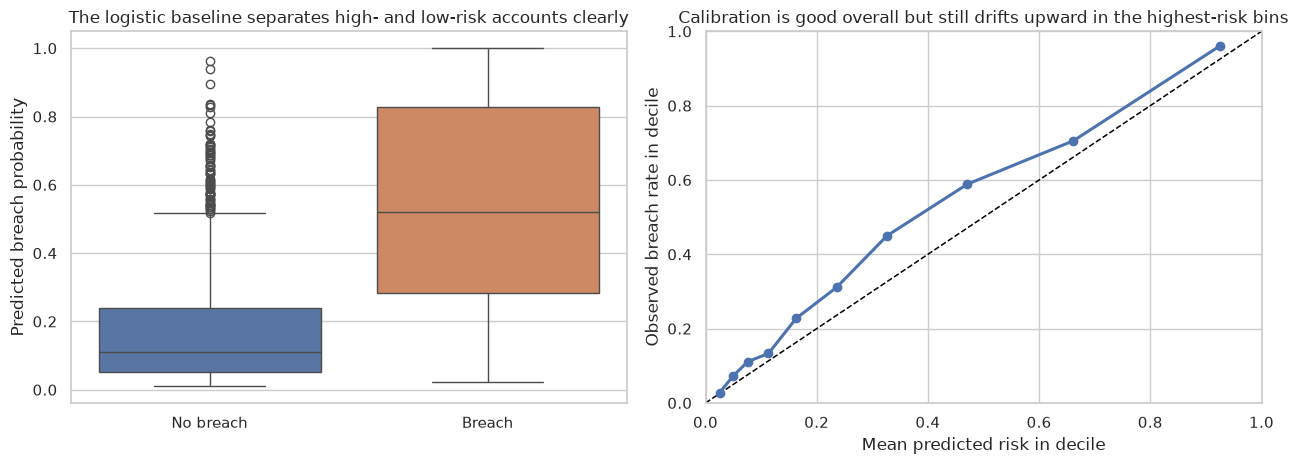

In [6]:
# Section focus: 4. Logistic Baseline for Breach Risk.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

prevalence_baseline_probability = train["breach_next_month"].mean()
prevalence_prediction = np.repeat(prevalence_baseline_probability, len(test))

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features, drop_first=True)),
        ("model", LogisticRegression(max_iter=4000)),
    ]
)
logistic_pipeline.fit(train[features], train["breach_next_month"])
breach_probability = logistic_pipeline.predict_proba(test[features])[:, 1]

classification_results = pd.DataFrame(
    [
        {
            "model": "Training-prevalence baseline",
            "roc_auc": roc_auc_score(test["breach_next_month"], prevalence_prediction),
            "pr_auc": average_precision_score(test["breach_next_month"], prevalence_prediction),
            "brier_score": brier_score_loss(test["breach_next_month"], prevalence_prediction),
            "mean_predicted_risk": prevalence_prediction.mean(),
        },
        {
            "model": "Logistic baseline",
            "roc_auc": roc_auc_score(test["breach_next_month"], breach_probability),
            "pr_auc": average_precision_score(test["breach_next_month"], breach_probability),
            "brier_score": brier_score_loss(test["breach_next_month"], breach_probability),
            "mean_predicted_risk": breach_probability.mean(),
        },
    ]
)
smart_display(classification_results.round(3))

test_classification = test.copy()
test_classification["predicted_risk"] = breach_probability
test_classification["observed_outcome"] = test_classification["breach_next_month"].map({0: "No breach", 1: "Breach"})

test_classification["risk_decile"] = pd.qcut(test_classification["predicted_risk"], 10, duplicates="drop")
calibration_by_decile = (
    test_classification.groupby("risk_decile", as_index=False)
    .agg(
        mean_predicted_risk=("predicted_risk", "mean"),
        observed_breach_rate=("breach_next_month", "mean"),
        rows=("breach_next_month", "size"),
    )
)
smart_display(calibration_by_decile.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

sns.boxplot(
    data=test_classification,
    x="observed_outcome",
    y="predicted_risk",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[0],
)
axes[0].set_title("The logistic baseline separates high- and low-risk accounts clearly")
axes[0].set_xlabel("")
axes[0].set_ylabel("Predicted breach probability")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.1)
axes[1].plot(
    calibration_by_decile["mean_predicted_risk"],
    calibration_by_decile["observed_breach_rate"],
    marker="o",
    linewidth=2.2,
)
axes[1].set_title("Calibration is good overall but still drifts upward in the highest-risk bins")
axes[1].set_xlabel("Mean predicted risk in decile")
axes[1].set_ylabel("Observed breach rate in decile")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


The practical question in Logistic Baseline for Breach Risk is simple. What would this result make the analyst do differently?


,categorical_field,reference_level
0,region,APAC
1,tier,Basic
2,industry,FinTech


,feature,log_odds_coefficient,odds_multiplier
3,backlog ratio,0.628,1.874
4,critical incidents 30d,0.583,1.792
6,prior escalation rate,0.466,1.594
5,avg response hours 30d,0.246,1.279
2,adoption breadth,-0.162,0.850
1,usage ratio,-0.062,0.940
0,active seats,0.015,1.015
7,release shock,0.000,1.000


,feature,log_odds_coefficient,odds_multiplier
9,region: LATAM vs APAC,0.343000,1.409000
11,tier: Growth vs Basic,-0.240000,0.786000
8,region: Europe vs APAC,0.157000,1.170000
12,tier: Premium vs Basic,-0.125000,0.882000
14,industry: Healthcare vs FinTech,0.118000,1.125000
16,industry: SaaS vs FinTech,-0.076000,0.927000
13,tier: Strategic vs Basic,-0.055000,0.947000
15,industry: Manufacturing vs FinTech,0.051000,1.053000


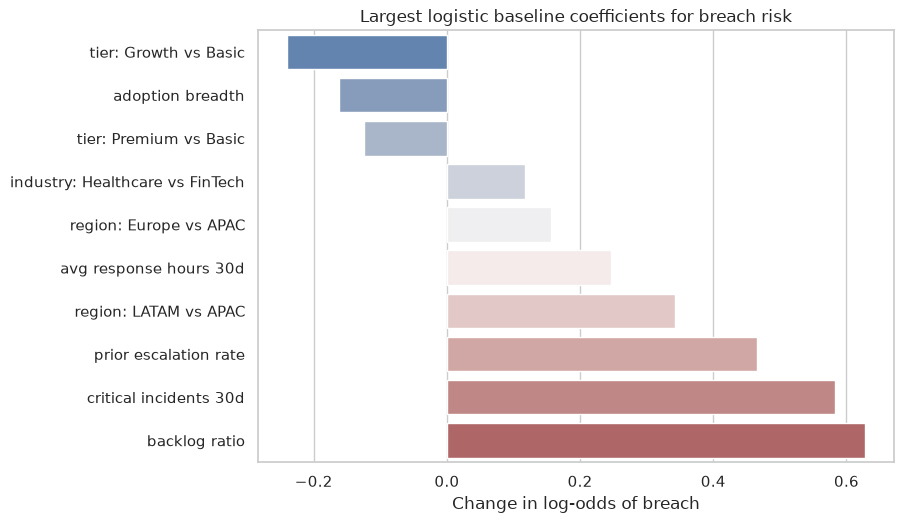

In [7]:
# Section focus: 4. Logistic Baseline for Breach Risk.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

logistic_coefficients, logistic_reference_levels = coefficient_frame(
    logistic_pipeline,
    model_kind="classification",
    categorical_features=categorical_features,
)

logistic_reference_table = pd.DataFrame(
    {
        "categorical_field": list(logistic_reference_levels.keys()),
        "reference_level": list(logistic_reference_levels.values()),
    }
)

logistic_top_numeric = logistic_coefficients[~logistic_coefficients["feature"].str.contains(":")].head(8)
logistic_top_categories = logistic_coefficients[logistic_coefficients["feature"].str.contains(":")].head(8)

smart_display(logistic_reference_table)
smart_display(logistic_top_numeric[["feature", "log_odds_coefficient", "odds_multiplier"]].round(3))
smart_display(logistic_top_categories[["feature", "log_odds_coefficient", "odds_multiplier"]].round(3))

plot_logistic_coefficients = logistic_coefficients.head(10).sort_values("log_odds_coefficient")
fig, ax = plt.subplots(figsize=(9.2, 5.4))
sns.barplot(data=plot_logistic_coefficients, x="log_odds_coefficient", y="feature", palette="vlag", ax=ax)
ax.set_title("Largest logistic baseline coefficients for breach risk")
ax.set_xlabel("Change in log-odds of breach")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Use the Logistic Baseline for Breach Risk output to decide what the analysis should do next. Read the pattern through the decision it could change.


### Discussion of the Logistic Baseline

The logistic baseline is already a serious operational model. It beats the training-prevalence baseline by a large margin on ROC AUC, PR AUC, and Brier score, and the calibration plot shows that predicted probabilities track realized breach rates reasonably well across most of the risk spectrum.

The coefficient summaries tell a coherent predictive story. Higher backlog, more prior escalation, and more critical incidents all raise breach risk. Higher usage and broader adoption reduce risk. The LATAM region also carries extra predictive risk relative to the dropped reference region in this synthetic environment.

Still, the highest predicted-risk bins run a little hotter than the model expects. That is a useful warning sign. Even when a logistic baseline is very strong overall, the tail may deserve extra monitoring because that is where the hardest operational decisions are usually concentrated.


## 5. Baselines as Anchors for Later Model Comparison

A baseline earns its place when it changes the burden of proof for later models. Instead of asking whether a more flexible model can improve performance at all, we ask a stricter question: **does the richer model improve enough to justify extra complexity, weaker interpretability, and greater monitoring burden?**

To make that concrete, we compare the linear and logistic baselines against histogram gradient boosting models on the same train-test split.


,model,mae,rmse,r_squared
0,Ridge linear baseline,6.411,7.721,0.667
1,Histogram gradient boosting,6.416,7.819,0.659


,model,roc_auc,pr_auc,brier_score
0,Logistic baseline,0.857,0.798,0.147
1,Histogram gradient boosting,0.850,0.785,0.151


,model,mean_residual_in_top_support_decile,mae_in_top_support_decile
0,Ridge linear baseline,10.965000,10.969000
1,Histogram gradient boosting,9.774000,10.450000


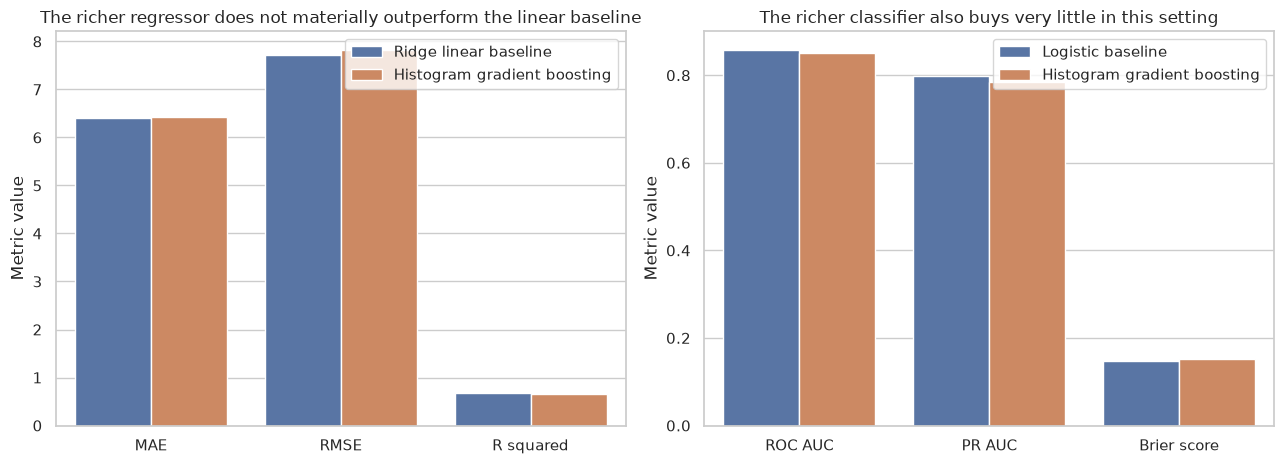

In [8]:
# Section focus: 5. Baselines as Anchors for Later Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

regression_boosting = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features, drop_first=True)),
        (
            "model",
            HistGradientBoostingRegressor(
                max_depth=4,
                learning_rate=0.05,
                max_iter=300,
                min_samples_leaf=25,
                random_state=0,
            ),
        ),
    ]
)
regression_boosting.fit(train[features], train["support_hours_next_month"])
support_prediction_boosting = regression_boosting.predict(test[features])

classification_boosting = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_features, categorical_features, drop_first=True)),
        (
            "model",
            HistGradientBoostingClassifier(
                max_depth=4,
                learning_rate=0.05,
                max_iter=250,
                min_samples_leaf=25,
                random_state=0,
            ),
        ),
    ]
)
classification_boosting.fit(train[features], train["breach_next_month"])
breach_probability_boosting = classification_boosting.predict_proba(test[features])[:, 1]

model_comparison_regression = pd.DataFrame(
    [
        {
            "model": "Ridge linear baseline",
            "mae": mean_absolute_error(test["support_hours_next_month"], support_prediction),
            "rmse": mean_squared_error(test["support_hours_next_month"], support_prediction) ** 0.5,
            "r_squared": r2_score(test["support_hours_next_month"], support_prediction),
        },
        {
            "model": "Histogram gradient boosting",
            "mae": mean_absolute_error(test["support_hours_next_month"], support_prediction_boosting),
            "rmse": mean_squared_error(test["support_hours_next_month"], support_prediction_boosting) ** 0.5,
            "r_squared": r2_score(test["support_hours_next_month"], support_prediction_boosting),
        },
    ]
)

model_comparison_classification = pd.DataFrame(
    [
        {
            "model": "Logistic baseline",
            "roc_auc": roc_auc_score(test["breach_next_month"], breach_probability),
            "pr_auc": average_precision_score(test["breach_next_month"], breach_probability),
            "brier_score": brier_score_loss(test["breach_next_month"], breach_probability),
        },
        {
            "model": "Histogram gradient boosting",
            "roc_auc": roc_auc_score(test["breach_next_month"], breach_probability_boosting),
            "pr_auc": average_precision_score(test["breach_next_month"], breach_probability_boosting),
            "brier_score": brier_score_loss(test["breach_next_month"], breach_probability_boosting),
        },
    ]
)

support_tail_cutoff = test["support_hours_next_month"].quantile(0.90)
residual_tail_summary = pd.DataFrame(
    [
        {
            "model": "Ridge linear baseline",
            "mean_residual_in_top_support_decile": (
                test["support_hours_next_month"] - support_prediction
            )[test["support_hours_next_month"] >= support_tail_cutoff].mean(),
            "mae_in_top_support_decile": (
                test["support_hours_next_month"] - support_prediction
            )[test["support_hours_next_month"] >= support_tail_cutoff].abs().mean(),
        },
        {
            "model": "Histogram gradient boosting",
            "mean_residual_in_top_support_decile": (
                test["support_hours_next_month"] - support_prediction_boosting
            )[test["support_hours_next_month"] >= support_tail_cutoff].mean(),
            "mae_in_top_support_decile": (
                test["support_hours_next_month"] - support_prediction_boosting
            )[test["support_hours_next_month"] >= support_tail_cutoff].abs().mean(),
        },
    ]
)

smart_display(model_comparison_regression.round(3))
smart_display(model_comparison_classification.round(3))
smart_display(residual_tail_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

comparison_reg_plot = model_comparison_regression.melt(id_vars="model", value_vars=["mae", "rmse", "r_squared"], var_name="metric", value_name="value")
comparison_reg_plot["metric"] = comparison_reg_plot["metric"].map({"mae": "MAE", "rmse": "RMSE", "r_squared": "R squared"})
sns.barplot(data=comparison_reg_plot, x="metric", y="value", hue="model", ax=axes[0])
axes[0].set_title("The richer regressor does not materially outperform the linear baseline")
axes[0].set_xlabel("")
axes[0].set_ylabel("Metric value")
axes[0].legend(title="")

comparison_cls_plot = model_comparison_classification.melt(id_vars="model", value_vars=["roc_auc", "pr_auc", "brier_score"], var_name="metric", value_name="value")
comparison_cls_plot["metric"] = comparison_cls_plot["metric"].map({"roc_auc": "ROC AUC", "pr_auc": "PR AUC", "brier_score": "Brier score"})
sns.barplot(data=comparison_cls_plot, x="metric", y="value", hue="model", ax=axes[1])
axes[1].set_title("The richer classifier also buys very little in this setting")
axes[1].set_xlabel("")
axes[1].set_ylabel("Metric value")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


In Baselines as Anchors for Later Model Comparison, the point of the output is practical. This is decision support when it clarifies what to tune, inspect, threshold, or govern.


### Discussion of the Model Comparison

This is one of the most important possible outcomes in applied machine learning: the richer model does **not** clearly justify itself. In this synthetic environment, the linear and logistic baselines are already doing most of the predictive work. The histogram boosting models are not catastrophically bad; they simply do not buy enough extra performance to dominate the simpler alternatives.

That is precisely why baselines matter. Without them, a team could easily celebrate a complex model for being "advanced" without noticing that the simpler model was already strong, faster to retrain, easier to explain, and cheaper to monitor.

The tail-residual table adds the final nuance. Even though the baseline is strong overall, it still underpredicts the highest support-burden decile. A richer model helps that tail only marginally here. So the right decision may not be "switch models." It may be "keep the baseline, add targeted monitoring for the operational tail, and only escalate complexity if later evidence demands it."


## 6. Practical Checklist for Baseline Modeling

| Question | Why it matters |
|---|---|
| What trivial null model should the baseline beat? | Prevents us from admiring models that add little beyond a constant prediction |
| Are numeric features standardized before coefficient interpretation? | Makes coefficient magnitudes more comparable across scales |
| Which category levels are the references? | Category coefficients are always relative to something |
| Are coefficients being interpreted predictively or causally? | Predictive association does not establish intervention effect |
| Does the baseline hold up in the operational tail? | Average performance can hide the cases that matter most |
| Does a richer model improve enough to justify its costs? | Complexity should earn its place, not receive it automatically |
| Are calibration and residual diagnostics checked in addition to headline metrics? | Good ranking alone does not guarantee useful probabilities or robust operational forecasts |

A disciplined baseline is not a ceremonial first draft. It is part of the finished analytical argument.


## Wrap-Up

Linear and logistic baselines remain central tools in decision science because they combine speed, interpretability, and competitive predictive strength. In this notebook, both baselines clearly beat trivial null models, and neither is convincingly dominated by the richer nonlinear alternative. That is exactly the kind of evidence that should shape modeling choices in practice.

The notebook also showed where simplicity has limits. The support-burden baseline still underpredicts the operational tail, and the breach model runs slightly warm in the highest-risk bins. Those are not reasons to discard the baselines. They are reasons to use them intelligently: as strong anchors, as diagnostic tools, and as the standard later models must surpass.

## References

- Breiman, L. (2001). *Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author).* *Statistical Science, 16*(3). [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726)
- Bzdok, D., Altman, N., & Krzywinski, M. (2018). *Statistics versus machine learning.* *Nature Methods, 15*(4), 233-234. [https://doi.org/10.1038/nmeth.4642](https://doi.org/10.1038/nmeth.4642)
- Domingos, P. (2012). *A few useful things to know about machine learning.* *Communications of the ACM, 55*(10), 78-87. [https://doi.org/10.1145/2347736.2347755](https://doi.org/10.1145/2347736.2347755)
- Van Calster, B., McLernon, D. J., van Smeden, M., et al. (2019). *Calibration: the Achilles heel of predictive analytics.* *BMC Medicine, 17*(1). [https://doi.org/10.1186/s12916-019-1466-7](https://doi.org/10.1186/s12916-019-1466-7)
